# Day 2. 생성형AI를 활용한 데이터분석
- 공공 부문 데이터 예측 모델 구축

✅ 라이브러리 로드 완료
Shape: (3000, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   접수ID       3000 non-null   object        
 1   접수일자       3000 non-null   datetime64[ns]
 2   기관유형       3000 non-null   object        
 3   기관명        3000 non-null   object        
 4   지역         3000 non-null   object        
 5   서비스분야      3000 non-null   object        
 6   민원채널       3000 non-null   object        
 7   신청자연령대     3000 non-null   object        
 8   취약계층여부     3000 non-null   int64         
 9   긴급도        3000 non-null   object        
 10  민원복잡도      3000 non-null   int64         
 11  담당인력수      3000 non-null   int64         
 12  첨부서류수      3000 non-null   int64         
 13  예산관련금액_만원  3000 non-null   int64         
 14  처리기준일수     3000 non-null   int64         
 15  실제처리일수     3000 non-null   int64         
 16  재문의횟수     

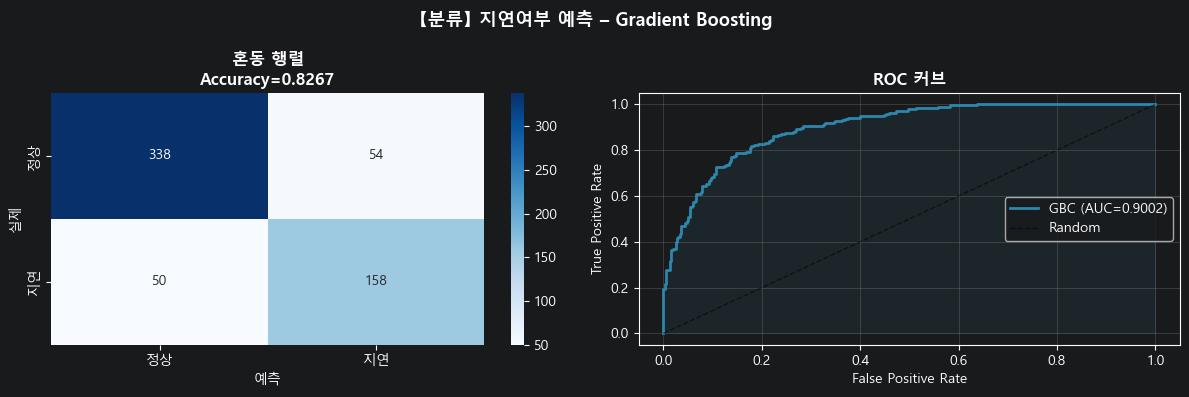

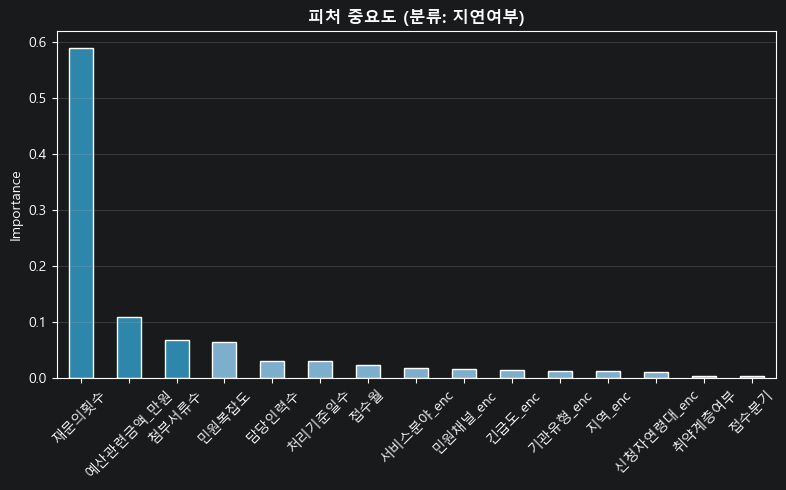


상위 5개 피처:
재문의횟수        0.589688
예산관련금액_만원    0.108969
첨부서류수        0.067821
민원복잡도        0.063139
담당인력수        0.030587
dtype: float64
✅ 학습 완료
R²   : 0.6370
MAE  : 0.3457
RMSE : 0.4529


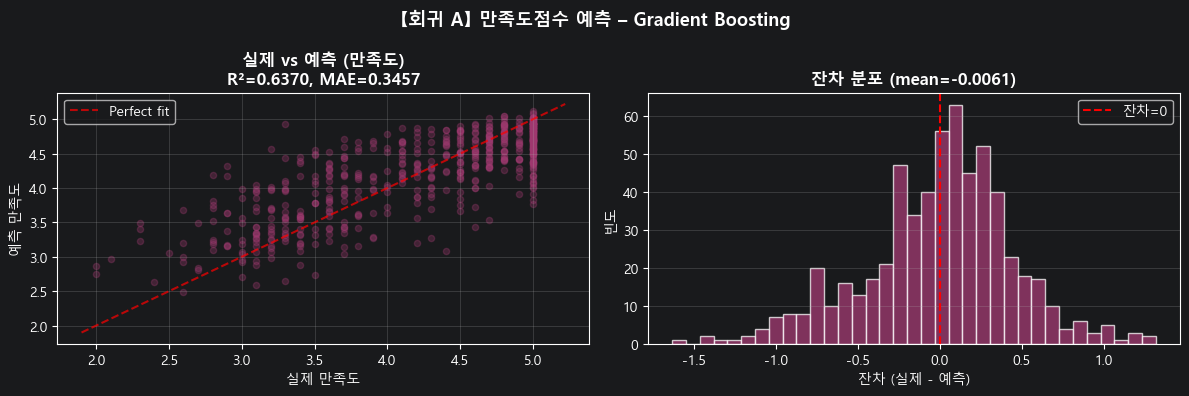

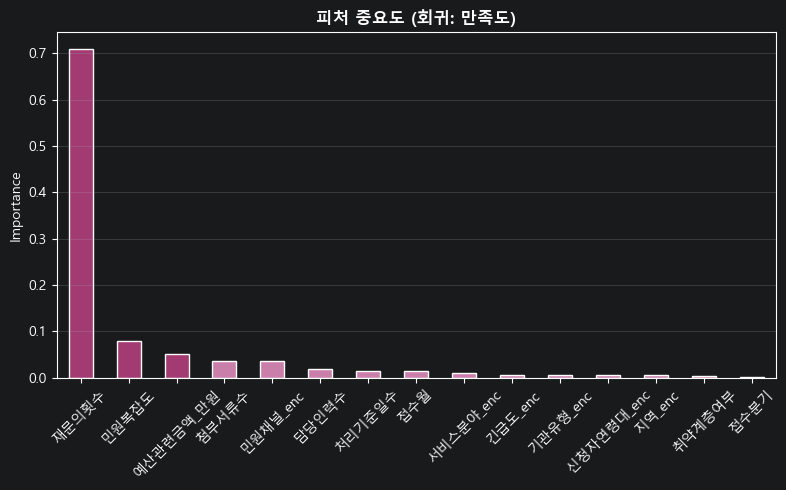

✅ 학습 완료

비영(non-zero) 계수 수: 9 / 15
R²   : 0.9008
MAE  : 3.91 만원
RMSE : 4.89 만원


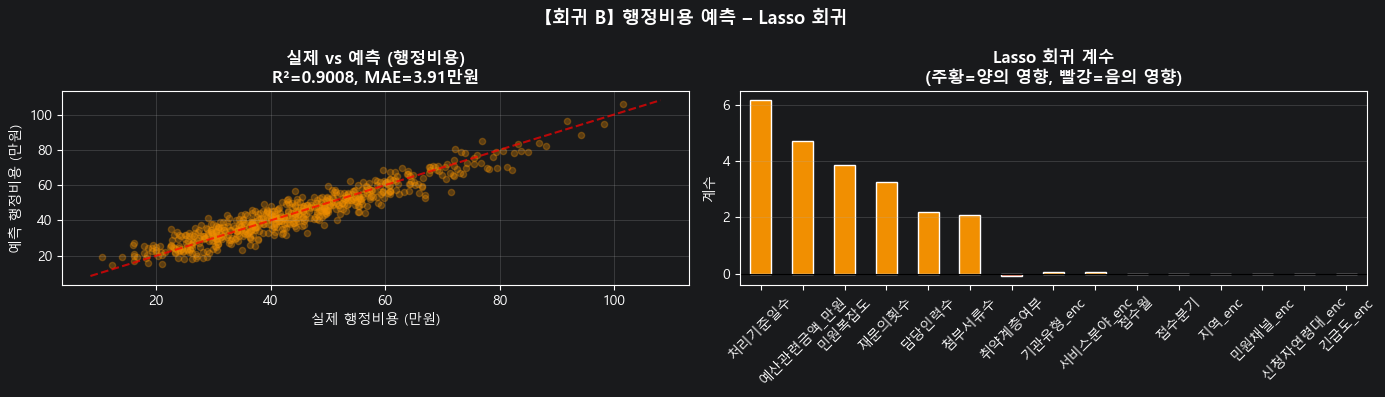

,모델,주요지표,값,Accuracy / R²,MAE,RMSE
태스크,,,,,,
분류 – 지연여부,Gradient Boosting,AUC,0.900200,0.826700,-,-
회귀 A – 만족도점수,Gradient Boosting,R²,0.637000,0.637000,0.345700,0.452900
회귀 B – 행정비용,Lasso 회귀,R²,0.900800,0.900800,3.91만원,4.89만원


In [1]:
"""
<prompt>
  <task>
    'public_sector_analysis_dataset_3000x20.xlsx' 엑셀 파일을 읽어서 예측 모델을 만들고자 한다.
    지도학습 분류와 회귀를 모두 할 것인다.
    jupyter notebook에서 실행하기 위한 python 코드를 작성하라.
  </task>
  <constraints>
    - 가장 대표적인 모델만 적용한다.
  </constraints>
</prompt>
"""

# 필요 시 설치
# !pip install scikit-learn pandas openpyxl matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.linear_model import Lasso
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

# ── 한글 폰트 설정 ──
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    import subprocess
    result = subprocess.run(['fc-list', ':lang=ko'], capture_output=True, text=True)
    ko_fonts = [l.split(':')[0].strip() for l in result.stdout.strip().split('\n') if l]
    if ko_fonts:
        plt.rcParams['font.family'] = fm.FontProperties(fname=ko_fonts[0]).get_name()

plt.rcParams['axes.unicode_minus'] = False
print('✅ 라이브러리 로드 완료')

# ── 파일 경로를 실제 위치에 맞게 수정하세요 ──
FILE_PATH = 'input/public_sector_analysis_dataset_3000x20.xlsx'

df = pd.read_excel(FILE_PATH)
print(f'Shape: {df.shape}')
df.head()

df.info()
df.describe()

print('결측치 현황:')
print(df.isnull().sum())
print(f'\n지연여부 분포:\n{df["지연여부"].value_counts()}')

# 피처 엔지니어링
# ── 날짜 파생 변수 ──
df['접수월']   = df['접수일자'].dt.month
df['접수분기'] = df['접수일자'].dt.quarter

# ── 범주형 인코딩 ──
cat_cols = ['기관유형', '지역', '서비스분야', '민원채널', '신청자연령대', '긴급도']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# 공통 피처 정의
FEATURES = [
    '취약계층여부', '민원복잡도', '담당인력수', '첨부서류수',
    '예산관련금액_만원', '처리기준일수', '재문의횟수',
    '접수월', '접수분기',
    '기관유형_enc', '지역_enc', '서비스분야_enc',
    '민원채널_enc', '신청자연령대_enc', '긴급도_enc'
]

X = df[FEATURES]
print(f'입력 피처 수: {len(FEATURES)}')
X.describe()

# 분류 모델
# ── 데이터 분할 ──
y_cls = df['지연여부']
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
print(f'Train: {X_tr_c.shape}, Test: {X_te_c.shape}')
print(f'Train 지연 비율: {y_tr_c.mean():.3f} | Test 지연 비율: {y_te_c.mean():.3f}')

# ── 모델 학습 ──
gbc = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42
)
gbc.fit(X_tr_c, y_tr_c)
print('✅ 학습 완료')

# ── 성능 평가 ──
y_pred_c = gbc.predict(X_te_c)
y_prob_c = gbc.predict_proba(X_te_c)[:, 1]

acc   = (y_pred_c == y_te_c).mean()
auc   = roc_auc_score(y_te_c, y_prob_c)
cv_auc = cross_val_score(gbc, X_tr_c, y_tr_c, cv=5, scoring='roc_auc').mean()

print(f'Accuracy : {acc:.4f}')
print(f'AUC      : {auc:.4f}')
print(f'CV-AUC   : {cv_auc:.4f} (5-fold)\n')
print(classification_report(y_te_c, y_pred_c, target_names=['정상', '지연']))

# ── 시각화: 혼동행렬 + ROC 커브 ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(y_te_c, y_pred_c)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['정상', '지연'], yticklabels=['정상', '지연'])
axes[0].set_title(f'혼동 행렬\nAccuracy={acc:.4f}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('실제'); axes[0].set_xlabel('예측')

fpr, tpr, _ = roc_curve(y_te_c, y_prob_c)
axes[1].plot(fpr, tpr, color='#2E86AB', lw=2, label=f'GBC (AUC={auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#2E86AB')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC 커브', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('【분류】 지연여부 예측 – Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ── 피처 중요도 ──
fi_cls = pd.Series(gbc.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2E86AB' if i < 3 else '#7DAECC' for i in range(len(fi_cls))]
fi_cls.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('피처 중요도 (분류: 지연여부)', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print('\n상위 5개 피처:'); print(fi_cls.head())

# 회귀 A (Gradient Boosting → 만족도)
y_sat = df['만족도점수']
X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X, y_sat, test_size=0.2, random_state=42)

gbr_sat = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42
)
gbr_sat.fit(X_tr_s, y_tr_s); print('✅ 학습 완료')

y_pred_s = gbr_sat.predict(X_te_s)
r2   = r2_score(y_te_s, y_pred_s)
mae  = mean_absolute_error(y_te_s, y_pred_s)
rmse = np.sqrt(mean_squared_error(y_te_s, y_pred_s))
print(f'R²   : {r2:.4f}'); print(f'MAE  : {mae:.4f}'); print(f'RMSE : {rmse:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_te_s, y_pred_s, alpha=0.3, s=20, color='#A23B72')
lims = [min(y_te_s.min(), y_pred_s.min()) - 0.1, max(y_te_s.max(), y_pred_s.max()) + 0.1]
axes[0].plot(lims, lims, 'r--', lw=1.5, alpha=0.7, label='Perfect fit')
axes[0].set_xlabel('실제 만족도'); axes[0].set_ylabel('예측 만족도')
axes[0].set_title(f'실제 vs 예측 (만족도)\nR²={r2:.4f}, MAE={mae:.4f}', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

residuals = y_te_s.values - y_pred_s
axes[1].hist(residuals, bins=35, color='#A23B72', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='red', lw=1.5, linestyle='--', label='잔차=0')
axes[1].set_xlabel('잔차 (실제 - 예측)'); axes[1].set_ylabel('빈도')
axes[1].set_title(f'잔차 분포 (mean={residuals.mean():.4f})', fontweight='bold')
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('【회귀 A】 만족도점수 예측 – Gradient Boosting', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

fi_sat = pd.Series(gbr_sat.feature_importances_, index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#A23B72' if i < 3 else '#C97FAA' for i in range(len(fi_sat))]
fi_sat.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('피처 중요도 (회귀: 만족도)', fontsize=12, fontweight='bold')
ax.set_ylabel('Importance'); ax.tick_params(axis='x', rotation=45); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# 회귀 B (Lasso → 행정비용)
# ── 데이터 분할 + 스케일링 ──
y_cost = df['행정비용추정_만원']
X_tr_co, X_te_co, y_tr_co, y_te_co = train_test_split(X, y_cost, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_tr_co_sc = scaler.fit_transform(X_tr_co)
X_te_co_sc  = scaler.transform(X_te_co)

lasso = Lasso(alpha=0.1, max_iter=5000)
lasso.fit(X_tr_co_sc, y_tr_co)
print('✅ 학습 완료')

coefs = pd.Series(lasso.coef_, index=FEATURES)
print(f'\n비영(non-zero) 계수 수: {(coefs != 0).sum()} / {len(FEATURES)}')

y_pred_co = lasso.predict(X_te_co_sc)
r2_co   = r2_score(y_te_co, y_pred_co)
mae_co  = mean_absolute_error(y_te_co, y_pred_co)
rmse_co = np.sqrt(mean_squared_error(y_te_co, y_pred_co))
print(f'R²   : {r2_co:.4f}'); print(f'MAE  : {mae_co:.2f} 만원'); print(f'RMSE : {rmse_co:.2f} 만원')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(y_te_co, y_pred_co, alpha=0.3, s=20, color='#F18F01')
lims2 = [min(y_te_co.min(), y_pred_co.min()) - 2, max(y_te_co.max(), y_pred_co.max()) + 2]
axes[0].plot(lims2, lims2, 'r--', lw=1.5, alpha=0.7)
axes[0].set_xlabel('실제 행정비용 (만원)'); axes[0].set_ylabel('예측 행정비용 (만원)')
axes[0].set_title(f'실제 vs 예측 (행정비용)\nR²={r2_co:.4f}, MAE={mae_co:.2f}만원', fontweight='bold')
axes[0].grid(alpha=0.3)

coef_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
bar_colors = ['#F18F01' if v > 0 else '#C73E1D' for v in coef_sorted.values]
coef_sorted.plot(kind='bar', ax=axes[1], color=bar_colors, edgecolor='white')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Lasso 회귀 계수\n(주황=양의 영향, 빨강=음의 영향)', fontweight='bold')
axes[1].set_ylabel('계수'); axes[1].tick_params(axis='x', rotation=45); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('【회귀 B】 행정비용 예측 – Lasso 회귀', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

#  최종 성능 요약
summary = pd.DataFrame([
    {'태스크': '분류 – 지연여부',    '모델': 'Gradient Boosting', '주요지표': 'AUC',
     '값': round(auc, 4), 'Accuracy / R²': round(acc, 4), 'MAE': '-', 'RMSE': '-'},
    {'태스크': '회귀 A – 만족도점수', '모델': 'Gradient Boosting', '주요지표': 'R²',
     '값': round(r2, 4),  'Accuracy / R²': round(r2, 4),  'MAE': round(mae, 4), 'RMSE': round(rmse, 4)},
    {'태스크': '회귀 B – 행정비용',  '모델': 'Lasso 회귀',        '주요지표': 'R²',
     '값': round(r2_co, 4), 'Accuracy / R²': round(r2_co, 4), 'MAE': f'{mae_co:.2f}만원', 'RMSE': f'{rmse_co:.2f}만원'},
])

summary.set_index('태스크', inplace=True)
summary.style.set_caption('모델 성능 최종 요약').set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]},
    {'selector': 'th',      'props': [('background-color', '#2E86AB'), ('color', 'white')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#EAF4FB')]},
])